In [1]:
from cnmodel import populations
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

--No graphics will be displayed.
[694042] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[694042] Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[694042] NumExpr defaulting to 16 threads.


## Functions

In [2]:
def get_response_map(levels, freqs, results, baseline, response, cell_type, cell_id):
    
    spont_spikes = 0
    spont_time = 0

    # calculate spontaneous firing rate
    for stim, iterations in list(results.values()):
        
        for vec in list(iterations.values()):
            
            spikes = vec[(cell_type, cell_id)][1]
            spont_spikes += ((spikes >= baseline[0]) * (spikes < baseline[1])).sum()
            spont_time += baseline[1] - baseline[0]

    spont_rate = spont_spikes / spont_time

    nreps = 1

    # calculate response firing rate
    matrix = np.zeros((len(levels), len(freqs)))

    for stim, iteration in list(results.values()):

        for i in range(nreps):

            vec = iteration[i]
            spikes = vec[(cell_type, cell_id)][1]
            n_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()

            freq = stim.key()['f0']
            level = stim.key()['dbspl']

            j = freqs.index(freq)
            i = levels.index(level)

            matrix[i,j] += n_spikes - spont_rate * (response[1] - response[0])
    
    return matrix

In [3]:
def get_cell_nspikes(cell_type, results, response, pyr_ids=None):
    n_spikes = []
    cell_ids = []

    for stim, iterations in results.values():
        rep_n_spikes = []
        rep_cell_ids = []
        for cell, vec in iterations.items():
            if isinstance(cell, str):
                continue
            save_rate = True if ('sgc' in cell_type) or (('pyr' in cell_type) and (cell[1] in pyr_ids)) else False
            if (cell_type in cell[0]) and save_rate:
                spikes = np.array(vec[1])
                num_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()
                rep_n_spikes.append(num_spikes)
                rep_cell_ids.append(cell[1])

        n_spikes.append(rep_n_spikes)
        cell_ids.append(rep_cell_ids)

    n_spikes = np.mean(n_spikes, axis=0)

    return cell_ids[0], np.array(n_spikes)

## Type III - 22 kHZ Characteristic Frequency

In [27]:
t3_syn_weights = {'sp': 0.00044,
                  'vp': 0.0006,
                  'dp': 0.002228}

### Response Map

In [4]:
results_od = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-single_cell-simple_syns-25fs_11ls-3nreps-III/SPx0.00044_VPx0.0006/25fs_11dbs_22000cf-results_od.pkl', 'rb'))
data_norm = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-single_cell-simple_syns-25fs_11ls-3nreps-III/SPx0.00044_VPx0.0006/DATA-25fs_11dbs_22000cf-response_map-norm.pkl', 'rb'))

In [5]:
freqs = data_norm['freqs']
freqs_log = data_norm['freqs_log']
levels = data_norm['levels']

In [6]:
stimpar = {
        "dur": 0.3,
        "pip": 0.1,
        "start": [0.125],       # equals response start in seconds
        "baseline": [25, 125],  # baseline duration has to equal response duration
        "response": [125, 225],
    }

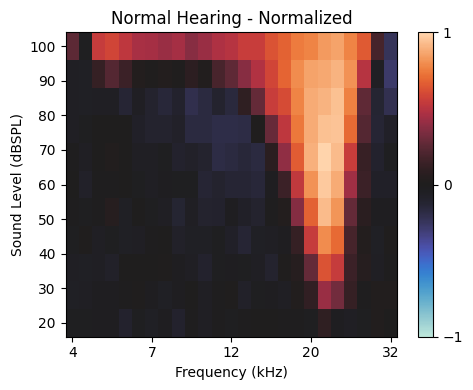

In [19]:
cmap = sns.color_palette("icefire", as_cmap=True)
# cmap = cm.twilight

fig, axs = plt.subplots(1,1,figsize=(5,4))  #, layout='constrained')

matrix = data_norm['matrix']
# matrix_norm = 2*((matrix - np.min(matrix))/(np.max(matrix) - np.min(matrix))) - 1
matrix_norm = matrix / np.max(np.abs(matrix))
im = axs.pcolormesh(freqs_log, levels, matrix_norm, cmap=cmap, vmin=-1, vmax=1) 
axs.set_title('Normal')
axs.set_ylabel('Sound Level (dBSPL)')
axs.set_xticks([freqs_log[i] for i in [0, 6, 12, 18, 24]])
axs.set_xticklabels([4, 7, 12, 20, 32])

# title = 'Hearing Loss' if 'loss' in self.hearing else 'Normal Hearing'
axs.set_title('Normal Hearing - Normalized')
axs.set_xlabel('Frequency (kHz)')

fig.colorbar(im, ticks=[-1,0,1])
# fig.set_dpi(200)
fig.tight_layout()

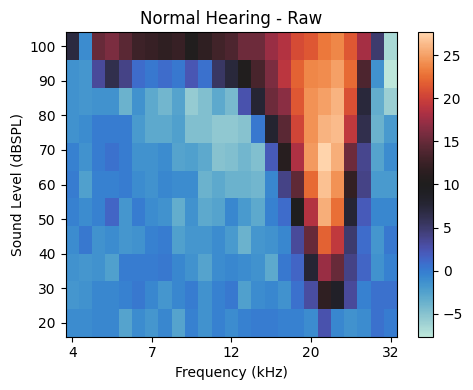

In [18]:
cmap = sns.color_palette("icefire", as_cmap=True)
# cmap = cm.twilight

fig, axs = plt.subplots(1,1,figsize=(5,4))  #, layout='constrained')

matrix = data_norm['matrix']
# matrix_norm = 2*((matrix - np.min(matrix))/(np.max(matrix) - np.min(matrix))) - 1
matrix_norm = matrix / np.max(np.abs(matrix))
im = axs.pcolormesh(freqs_log, levels, matrix, cmap=cmap)  #, vmin=-1, vmax=1) 
axs.set_title('Normal')
axs.set_ylabel('Sound Level (dBSPL)')
axs.set_xticks([freqs_log[i] for i in [0, 6, 12, 18, 24]])
axs.set_xticklabels([4, 7, 12, 20, 32])

# title = 'Hearing Loss' if 'loss' in self.hearing else 'Normal Hearing'
axs.set_title('Normal Hearing - Raw')
axs.set_xlabel('Frequency (kHz)')

fig.colorbar(im)  #, ticks=[-1,0,1])
# fig.set_dpi(200)
fig.tight_layout()

### Rate Level Curves

In [10]:
data_norm_below_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_below_cf = data_norm_below_cf['freqs'][0]
levels_below_cf = data_norm_below_cf['levels']

data_norm_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_cf = data_norm_cf['freqs'][0]
levels_cf = data_norm_cf['levels']

data_norm_above_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_above_cf = data_norm_above_cf['freqs'][0]
levels_above_cf = data_norm_above_cf['levels']

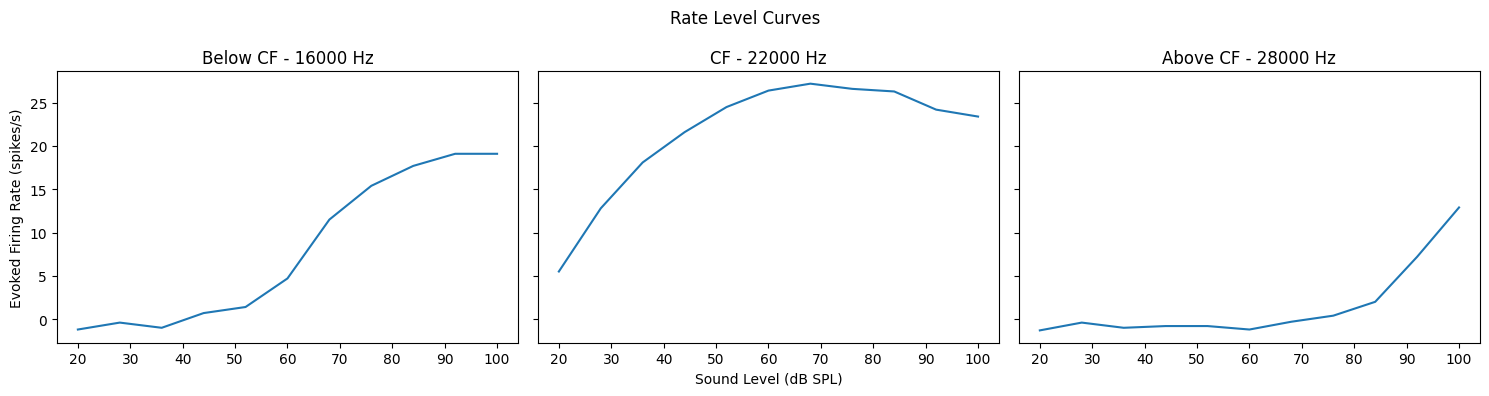

In [14]:
fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

axs[0].plot(levels_below_cf, data_norm_below_cf['matrix'])
axs[0].set_title(f'Below CF - {freq_below_cf} Hz')

axs[1].plot(levels_cf, data_norm_cf['matrix'])
axs[1].set_title(f'CF - {freq_cf} Hz')

axs[2].plot(levels_above_cf, data_norm_above_cf['matrix'])
axs[2].set_title(f'Above CF - {freq_above_cf} Hz')

axs[1].set_xlabel('Sound Level (dB SPL)')
axs[0].set_ylabel('Evoked Firing Rate (spikes/s)')

fig.suptitle('Rate Level Curves')

fig.tight_layout()

#### Tuning DS->Pyr

In [ ]:
sp_weight = t3_syn_weights['sp']
vp_weight = t3_syn_weights['vp']

In [21]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

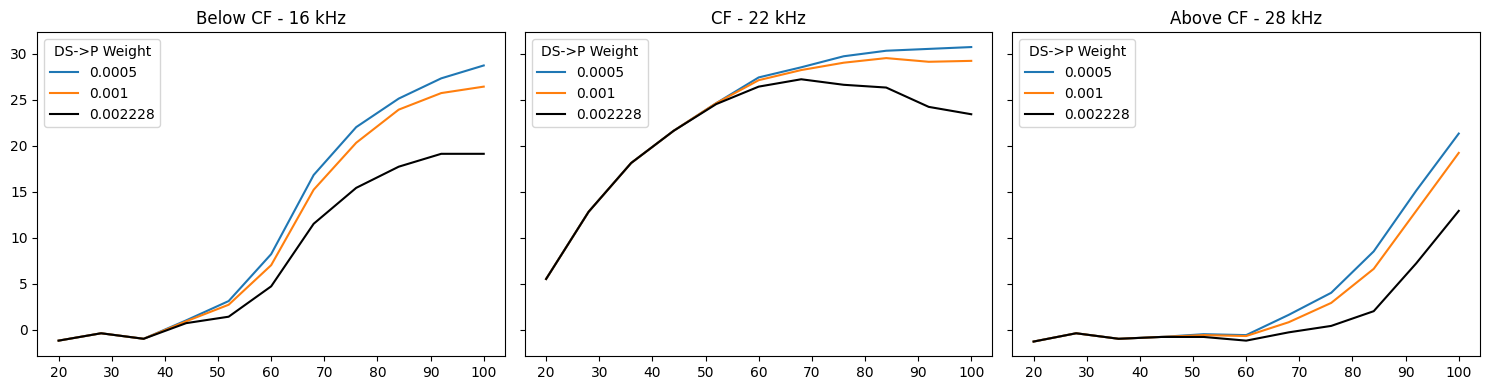

In [29]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'SPx{sp_weight}' in subdir_name) and (f'VPx{vp_weight}' in subdir_name):

                ds_weight = subdir_name.split('_')[2].split('DPx')[-1]

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if float(ds_weight) == t3_syn_weights['dp']:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], color='k', label=ds_weight)
                else:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], label=ds_weight)


    axs[i].legend(loc='upper left', title='DS->P Weight')
    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

fig.tight_layout()

#### Tuning Vert->Pyr

In [30]:
sp_weight = t3_syn_weights['sp']
dp_weight = t3_syn_weights['dp']

In [16]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

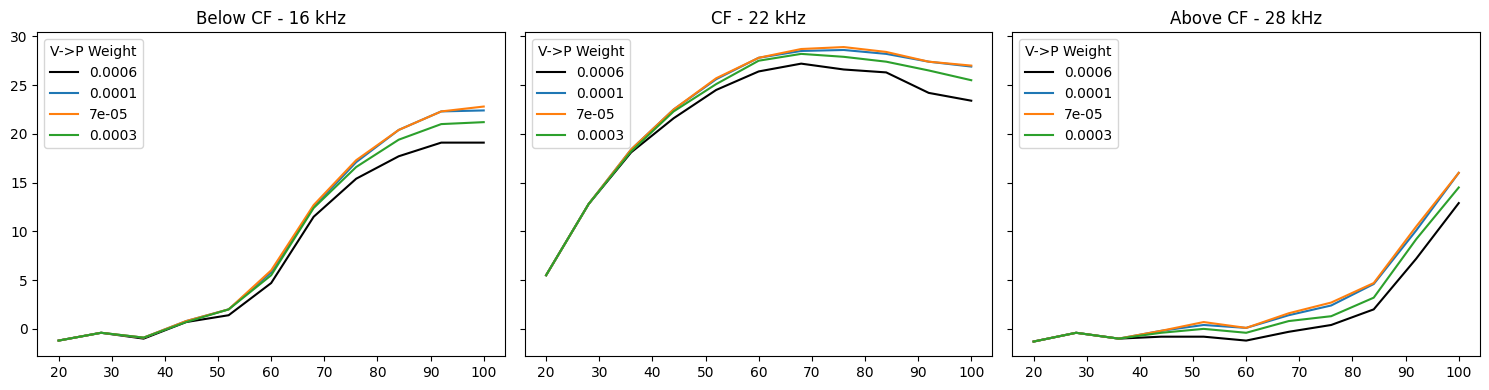

In [ ]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'SPx{sp_weight}' in subdir_name) and (f'DPx{dp_weight}' in subdir_name):

                vert_weight = float(subdir_name.split('_')[1].split('VPx')[-1])

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if vert_weight == t3_syn_weights['vp']:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], color='k', label=vert_weight)
                else:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], label=vert_weight)

    axs[i].legend(loc='upper left', title='V->P Weight')
    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

# axs[-1].legend(loc='upper le', title='V->P Weight')

fig.tight_layout()

#### Tuning SGN->Pyr

In [33]:
vp_weight = t3_syn_weights['vp']
dp_weight = t3_syn_weights['dp']

In [34]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

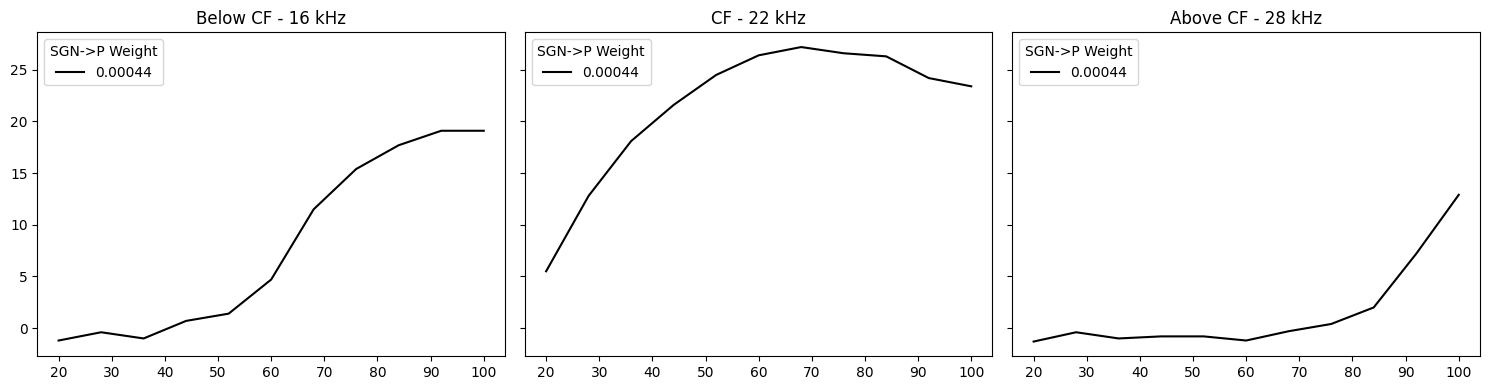

In [35]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'VPx{vp_weight}' in subdir_name) and (f'DPx{dp_weight}' in subdir_name):

                sgc_weight = float(subdir_name.split('_')[0].split('SPx')[-1])

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if sgc_weight == t3_syn_weights['sp']:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], color='k', label=sgc_weight)
                else:
                    axs[i].plot(subdir_levels, subdir_data_norm['matrix'], label=sgc_weight)
                # if sgc_weight == :

    axs[i].legend(loc='upper left', title='SGN->P Weight')
    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

# axs[-1].legend(loc='upper le', title='V->P Weight')

fig.tight_layout()

### PSTH

In [4]:
stimpar = {
        "dur": 0.3,
        "pip": 0.1,
        "start": [0.125],       # equals response start in seconds
        "baseline": [25, 125],  # baseline duration has to equal response duration
        "response": [125, 225],
    }

In [5]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')

pop_cfs = {'pyramidal': pyr_cfs,
           'sgc': sgc_cfs,
           'tuberculoventral': vert_cfs,
           'dstellate': ds_cfs}

pyr_id = pyr_pop.select(1, cf=22e3,create=True)
pyr_cell = pyr_pop.get_cell(pyr_id)

sgc_pop.connect(pyr_pop, ds_pop, vert_pop)
ds_pop.connect(pyr_pop, vert_pop)
vert_pop.connect(pyr_pop)
pyr_pop.resolve_inputs(depth=1)

sgc_in_ids = list(pyr_pop._pre_connections[0]._cell_indexes.values())

pre: sgc, post: pyramidal
pyramidal 2340: 48 sgc
pre: dstellate, post: pyramidal
pyramidal 2340: 15 dstellate
pre: tuberculoventral, post: pyramidal
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
pyramidal 2340: 21 tuberculoventral


In [19]:
freq =  22000
level = 60
resp_type = 'III'
sgc_pyr = 0.00044 if 'III' in resp_type else 0.00038  # type III - 0.00044, type IV - 0.00038, default - 0.000327
vert_pyr = 0.0006 if 'III' in resp_type else 0.0039  # type III - 0.0006, type IV - 0.0039, default - 0.0027
results_od = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/single_sound-single_cell-simple_syns-{freq}Hz_{level}dB-10nreps-{resp_type}/SPx{sgc_pyr}_VPx{vert_pyr}/1fs_1dbs_22000cf-results_od.pkl', 'rb'))

In [20]:
cell_types = ['pyramidal','tuberculoventral', 'dstellate', 'sgc']

colors = {'pyramidal': 'tab:blue',
          'tuberculoventral': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

cell_ids = {cell_type: [] for cell_type in cell_types}
cell_spikes = {cell_type: [] for cell_type in cell_types}

single_cell_ids = {'dstellate': 502,
                   'tuberucloventral': 3831,
                   'sgc': 7810}

cell_count = 0
trials = results_od[f'f0: {freq}  dBspl: {level}'][1]

for trial, cells in trials.items():
    for vec in cells.items():
        temp = 7
        if isinstance(vec[0], str):
            t = vec[1]
            continue

        cell_type = vec[0][0]
        cell_id = vec[0][1]
        spikes = vec[1][1]

        if 'pyr' in cell_type:
            pyr_trace = vec[1][0]

        if cell_type in single_cell_ids.keys():
            if cell_id == single_cell_ids[cell_type]:
                cell_ids[cell_type].append(cell_id)
                cell_spikes[cell_type].append(spikes)
        else:
            cell_ids[cell_type].append(cell_id)
            cell_spikes[cell_type].append(spikes)

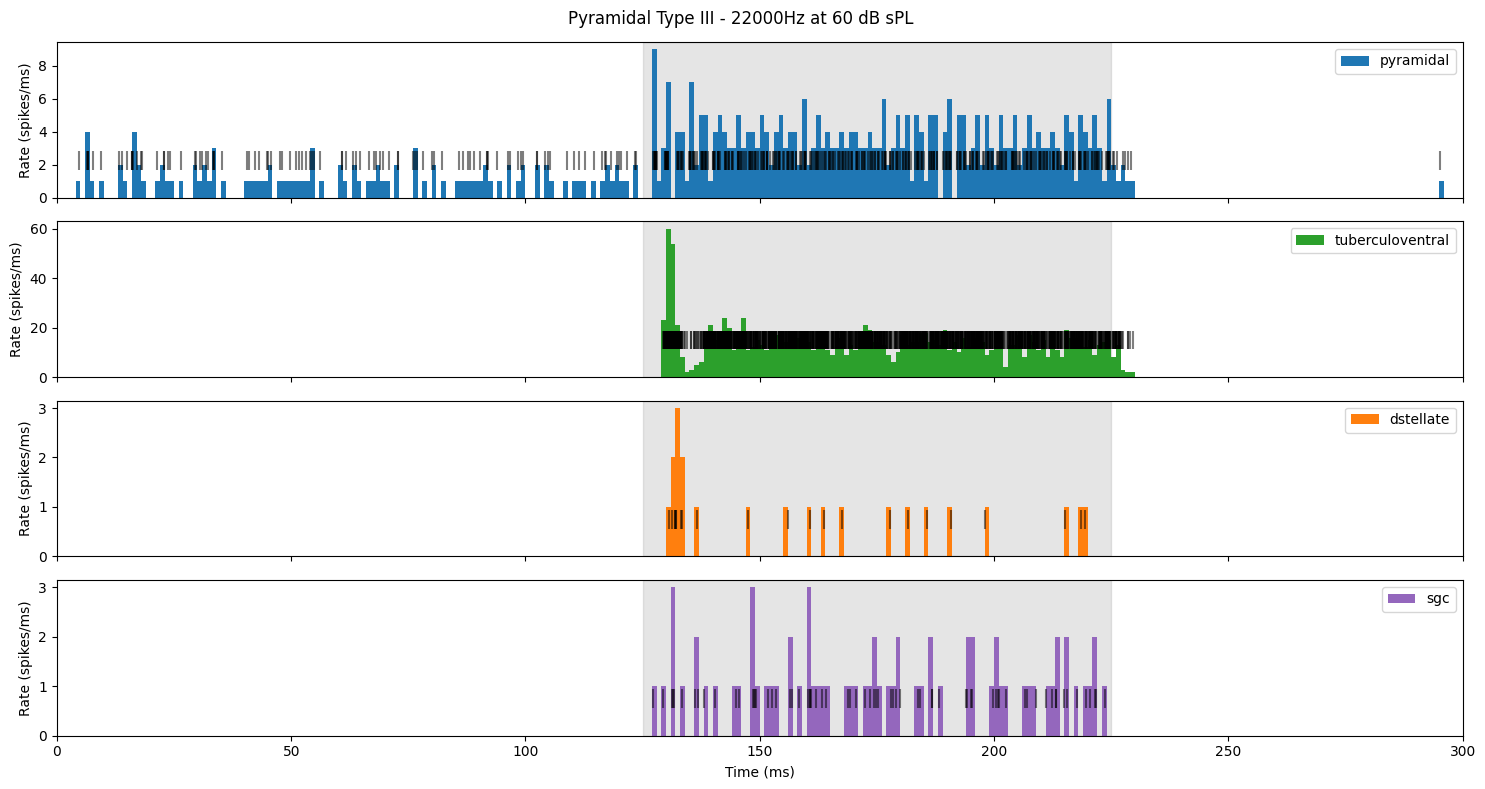

In [21]:
fig, axs = plt.subplots(len(cell_types), 1, figsize=(15,8), sharex=True, sharey=False)
axs = axs.ravel() 

for i, cell_type in enumerate(cell_types):

    cell_spike_times = np.concatenate(cell_spikes[cell_type])

    bin_size = 0.001  # 1 ms
    bins = np.arange(0, stimpar['dur']+bin_size, bin_size)

    counts, edges = np.histogram(cell_spike_times / 1000, bins=bins)

    psth = counts * (bin_size * 1000)  # spikes / s
    bin_centers = edges[:-1] + bin_size / 2

    axs[i].axvspan(stimpar['response'][0]/1000, stimpar['response'][1]/1000, color='grey', alpha=0.2)

    axs[i].bar(bin_centers, psth, width=bin_size, color=colors[cell_type], label=cell_type)

    axs[i].eventplot(cell_spike_times/1000, lineoffsets=psth.max()/4, linelengths=psth.max()/8, color='k', alpha=0.5)

    axs[i].set_ylabel('Rate (spikes/ms)')

    locs = axs[i].get_xticks()
    axs[i].set_xticks(locs)
    axs[i].set_xticklabels([int(loc*1000) for loc in locs])
    axs[i].set_xlim([0,(stimpar['dur'])])

    axs[i].legend(loc='upper right')

    # axs[i].set_title(cell_type)

axs[-1].set_xlabel('Time (ms)')

fig.suptitle(f'Pyramidal Type {resp_type} - {freq }Hz at {level} dB sPL')
fig.tight_layout()
fig.savefig(f'SPC_PSTH-{freq}Hz_{level}dB-{resp_type}.png', dpi=300)